# Fase 5: análise exploratória do painel PEDE

Este notebook corresponde à segunda etapa da Fase 5 do Datathon Passos Mágicos.

O objetivo é explorar o painel consolidado construído no notebook `01_limpeza_e_preparacao.ipynb`, buscando identificar padrões, associações e mudanças ao longo do período de 2022 a 2024.

O painel reúne **3.030 observações aluno-ano**. As análises longitudinais são realizadas somente quando o mesmo estudante possui registros nos anos comparados, evitando interpretar diferenças de composição da população como evolução individual.

Alguns cuidados metodológicos orientam toda a análise:

- A defasagem calculada diminui no agregado entre 2022 e 2024. Essa é uma descrição do painel observado e, isoladamente, não permite atribuir essa mudança ao programa, pois a composição dos estudantes pode variar entre os anos.
- `INDE` é um índice composto pelos indicadores do PEDE. Portanto, associações entre seus componentes e o próprio INDE são esperadas em parte pela própria construção do índice e não constituem evidência de causalidade.
- `IPP` está disponível somente a partir de 2023.
- A `Pedra` fornecida pela fonte não é reproduzida integralmente pelas faixas utilizadas no recálculo a partir do INDE. Por isso, a classificação fornecida e a classificação recalculada são tratadas separadamente.

Este notebook responde exploratoriamente às 11 perguntas oficiais do Datathon. Ele não realiza o treinamento do modelo preditivo. A modelagem, a validação temporal e a avaliação de desempenho são apresentadas no `03_modelagem_risco_temporal.ipynb`.

## Contexto e método

**Fonte:** `data/processed/pede_painel_consolidado.csv`, gerado a partir das planilhas PEDE 2022–2024. O contrato de dados está documentado em `docs/contrato_de_dados.md`.

### Premissas importantes

- O grão da análise é estudante anônimo (`RA`) por ano (`ANO`). O identificador `RA` não é exibido nos resultados.
- A defasagem é calculada como `FASE - FASE_IDEAL`. Valores negativos indicam que o estudante está abaixo da fase esperada.
- Para algumas visualizações, utilizamos as seguintes faixas operacionais:
  - **em fase ou adiantado:** `>= 0`;
  - **defasagem moderada:** `-1`;
  - **defasagem severa:** `<= -2`.
  
  Essas faixas são utilizadas exclusivamente para facilitar a análise e a visualização da distância em relação à fase esperada. Não substituem uma classificação pedagógica oficial.
- Comparações longitudinais utilizam somente estudantes observados nos dois períodos analisados. Entradas e saídas de estudantes podem alterar as médias agregadas.
- Correlações descrevem associações entre variáveis. Elas não permitem, isoladamente, concluir que uma variável causa mudança em outra.
- Quando uma análise compara anos diferentes, a disponibilidade dos indicadores também é considerada, pois alguns indicadores não foram coletados ou preenchidos da mesma forma em todo o período.

### Como navegar

A partir da seção **Dados**, o notebook responde às 11 perguntas oficiais do Datathon, na ordem apresentada no desafio.

Cada pergunta apresenta a análise correspondente e termina com uma leitura dos resultados, destacando também os principais cuidados necessários para sua interpretação.

In [ ]:
# Configura as bibliotecas e a visualização, localiza e carrega o painel consolidado,
# importa funções para análise longitudinal e exibe a estrutura da base, o número
# de alunos e a quantidade de registros por ano.

import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

sns.set_theme(style="whitegrid", context="notebook")
PALETA = {2022: "#315C8D", 2023: "#C58A22", 2024: "#7E9F67"}

raiz = Path.cwd().resolve()
if raiz.name == "notebooks":
    raiz = raiz.parent
sys.path.append(str(raiz))
from src.eda_utils import construir_pares_anos_consecutivos, filtrar_alunos_com_todos_os_anos

caminho_painel = raiz / "data" / "processed" / "pede_painel_consolidado.csv"
painel = pd.read_csv(caminho_painel)

indicadores = ["IAN", "IDA", "IEG", "IAA", "IPS", "IPP", "IPV"]
print(f"Fonte: {caminho_painel.relative_to(raiz)}")
print(f"Grão: aluno-ano | linhas: {len(painel):,} | alunos únicos: {painel['RA'].nunique():,}")
print("Linhas por ano:", painel.groupby("ANO").size().to_dict())


Fonte: data/processed/pede_painel_consolidado.csv
Grão: aluno-ano | linhas: 3,030 | alunos únicos: 1,661
Linhas por ano: {2022: 860, 2023: 1014, 2024: 1156}


## Dados

Antes de iniciar as perguntas de negócio, verificamos a cobertura do painel e a disponibilidade das principais variáveis utilizadas nas análises.

Essa etapa é importante porque nem todos os estudantes possuem registros nos três anos e alguns indicadores apresentam disponibilidade diferente entre as edições da PEDE.

Além disso, o último ano disponível no painel é 2024. Como não existe `PEDE2025` na fonte, não é possível observar o resultado do ano seguinte para os registros de 2024. Por isso, o alvo futuro utilizado na modelagem não está definido para esse ano.

In [ ]:
# Calcula a sobreposição de estudantes entre anos consecutivos, mostrando quantos
# alunos aparecem nas duas bases e qual percentual representam nas coortes de origem e destino.

anos = sorted(painel["ANO"].unique())
conjunto_ra = {ano: set(painel.loc[painel["ANO"].eq(ano), "RA"]) for ano in anos}

cobertura = []
for origem, destino in zip(anos, anos[1:]):
    comuns = conjunto_ra[origem] & conjunto_ra[destino]
    cobertura.append({
        "Transição": f"{origem}→{destino}",
        "Estudantes nas duas PEDEs": len(comuns),
        "% da coorte de origem": len(comuns) / len(conjunto_ra[origem]),
        "% da coorte de destino": len(comuns) / len(conjunto_ra[destino]),
    })

pd.DataFrame(cobertura).style.format({"% da coorte de origem": "{:.1%}", "% da coorte de destino": "{:.1%}"})


,Transição,Estudantes nas duas PEDEs,% da coorte de origem,% da coorte de destino
0,2022→2023,600,69.8%,59.2%
1,2023→2024,765,75.4%,66.2%


In [ ]:
# Calcula o percentual de valores ausentes, por ano, nos principais indicadores
# e variáveis do painel e apresenta os resultados em uma tabela com gradiente de cores.

ausencia = (
    painel.groupby("ANO")[indicadores + ["INDE", "PEDRA", "NOTA_INGLES"]]
    .apply(lambda dados: dados.isna().mean())
    .T
    .mul(100)
    .round(1)
)
ausencia.style.format("{:.1f}%").background_gradient(cmap="Oranges", axis=None)


ANO,2022,2023,2024
IAN,0.0%,0.0%,0.0%
IDA,0.0%,7.6%,8.7%
IEG,0.0%,7.5%,0.0%
IAA,0.0%,6.2%,8.8%
IPS,0.0%,6.8%,8.8%
IPP,100.0%,7.5%,8.8%
IPV,0.0%,7.5%,8.8%
INDE,0.0%,8.2%,8.8%
PEDRA,0.0%,8.2%,8.8%
NOTA_INGLES,67.1%,67.1%,59.0%


## Perguntas de negócio

As seções seguintes respondem, na ordem oficial, às 11 perguntas propostas pelo Datathon.

A análise combina estatísticas descritivas, comparações longitudinais e medidas de associação. Sempre que uma conclusão depender de uma associação estatística, ela será apresentada como associação e não como relação causal.

### Pergunta 1: Perfil geral de defasagem (IAN) e evolução ao longo do período

O objetivo desta análise é descrever a evolução da defasagem dos estudantes entre 2022 e 2024.

Utilizamos a `defasagem_calculada`, construída a partir de `FASE - FASE_IDEAL` e validada no notebook de preparação.

A análise inicialmente apresenta a visão agregada por ano. Como a composição dos estudantes pode mudar entre as edições, essa leitura deve ser complementada pelas análises longitudinais com coortes pareadas.

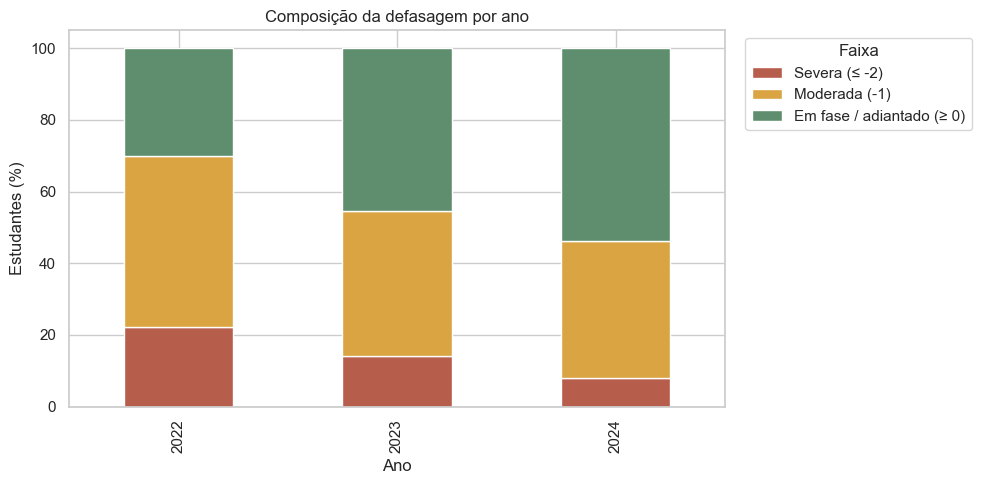

,estudantes,defasagem_media,percentual_defasados,ian_medio
ANO,,,,
2022,860,-0.943000,69.9%,6.424000
2023,1014,-0.655000,54.4%,7.244000
2024,1156,-0.414000,46.2%,7.684000


In [ ]:
# Classifica os alunos por faixa de defasagem, calcula a distribuição dessas faixas
# por ano e gera um gráfico comparativo. Em seguida, resume por ano o número de
# estudantes, a defasagem média, o percentual de alunos defasados e o IAN médio.

painel["FAIXA_DEFASAGEM"] = pd.cut(
    painel["DEFASAGEM_CALCULADA"],
    bins=[-np.inf, -2, -1, np.inf],
    labels=["Severa (≤ -2)", "Moderada (-1)", "Em fase / adiantado (≥ 0)"],
)
ordem_faixas = ["Severa (≤ -2)", "Moderada (-1)", "Em fase / adiantado (≥ 0)"]
perfil_defasagem = pd.crosstab(painel["ANO"], painel["FAIXA_DEFASAGEM"], normalize="index").reindex(columns=ordem_faixas)
ax = (perfil_defasagem * 100).plot(kind="bar", stacked=True, figsize=(10, 5), color=["#B75D4B", "#D9A441", "#5F8E6E"])
ax.set(title="Composição da defasagem por ano", xlabel="Ano", ylabel="Estudantes (%)")
ax.legend(title="Faixa", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

resumo_defasagem = painel.groupby("ANO").agg(
    estudantes=("RA", "size"),
    defasagem_media=("DEFASAGEM_CALCULADA", "mean"),
    percentual_defasados=("DEFASAGEM_CALCULADA", lambda serie: (serie < 0).mean()),
    ian_medio=("IAN", "mean"),
).round(3)
resumo_defasagem.style.format({"percentual_defasados": "{:.1%}"})


**Leitura:** a tendência agregada deve ser interpretada junto com a cobertura longitudinal apresentada nesta análise. Uma mudança na média anual pode resultar tanto de mudanças no desempenho dos estudantes quanto de mudanças na composição da população observada em cada ano.

Portanto, a tendência agregada descreve o comportamento do painel, mas não deve ser interpretada automaticamente como evolução individual dos estudantes ou como efeito do programa.

### Pergunta 2: Desempenho acadêmico (IDA): melhorando, estagnado ou caindo?

Depois de analisar a defasagem agregada, avaliamos a evolução individual do `IDA`.

Para isso, comparamos cada estudante consigo mesmo entre dois anos consecutivos. Essa abordagem utiliza **coortes pareadas**, permitindo observar a mudança entre os períodos para estudantes que possuem registro nos dois anos.

Essa estratégia reduz o risco de interpretar uma alteração na composição da população como mudança no desempenho individual.

In [ ]:
# Pareia os mesmos alunos entre anos consecutivos (2022-2023 e 2023-2024)
# e calcula a variação média do INDE, IDA, IEG e da defasagem para cada transição.

coortes_pareadas = []
for origem, destino in [(2022, 2023), (2023, 2024)]:
    antes = painel.loc[painel["ANO"].eq(origem), ["RA", "INDE", "IDA", "IEG", "DEFASAGEM_CALCULADA"]]
    depois = painel.loc[painel["ANO"].eq(destino), ["RA", "INDE", "IDA", "IEG", "DEFASAGEM_CALCULADA"]]
    pareado = antes.merge(depois, on="RA", suffixes=("_origem", "_destino"))
    coortes_pareadas.append({
        "Transição": f"{origem}→{destino}",
        "n pareado": len(pareado),
        "INDE médio": (pareado["INDE_destino"] - pareado["INDE_origem"]).mean(),
        "IDA médio": (pareado["IDA_destino"] - pareado["IDA_origem"]).mean(),
        "IEG médio": (pareado["IEG_destino"] - pareado["IEG_origem"]).mean(),
        "defasagem média": (pareado["DEFASAGEM_CALCULADA_destino"] - pareado["DEFASAGEM_CALCULADA_origem"]).mean(),
    })

pd.DataFrame(coortes_pareadas).round(3)


,Transição,n pareado,INDE médio,IDA médio,IEG médio,defasagem média
0,2022→2023,600,-0.025,0.115,0.235,0.157
1,2023→2024,765,-0.050,-0.478,-0.947,0.265


In [ ]:
# Calcula a média do IDA por fase e ano, reorganizando o resultado em uma
# tabela que permite comparar o desempenho entre as diferentes fases ao longo dos anos.

ida_fase_ano = (
    painel
    .groupby(["ANO", "FASE"])["IDA"]
    .mean()
    .unstack()
    .round(2)
)

display(ida_fase_ano)

FASE,0.0,1.0,2.0,3.0,4.0,5.0,6.0,7.0,8.0,9.0
ANO,,,,,,,,,,
2022,7.14,6.46,5.41,5.14,6.05,5.87,6.69,5.25,NaN,NaN
2023,7.42,6.81,6.74,5.75,6.00,5.90,6.81,7.81,NaN,NaN
2024,7.32,6.79,6.25,5.35,5.88,6.45,7.23,5.81,8.0,NaN


**Leitura:** o IDA médio pareado apresenta uma pequena elevação entre 2022 e 2023 (+0,115; n=600) e uma redução mais acentuada entre 2023 e 2024 (-0,478; n=765).

Descritivamente, os resultados mostram uma pequena variação positiva na primeira transição e uma variação negativa maior na segunda. Como as duas transições utilizam coortes pareadas diferentes, com tamanhos de amostra distintos, a comparação entre os dois deltas é descritiva e não constitui um teste formal de diferença entre períodos.

### Pergunta 3: Engajamento (IEG) × desempenho (IDA) × ponto de virada (IPV)

Nesta etapa, analisamos a relação entre engajamento, desempenho acadêmico e ponto de virada.

Primeiro, comparamos as médias dos indicadores por ano para obter uma visão descritiva do período. Em seguida, utilizamos correlações de Spearman para avaliar a associação entre `IDA`, `IEG` e `IPV`.

As correlações permitem identificar se os indicadores tendem a variar conjuntamente, mas não permitem determinar se mudanças em um deles provocam mudanças nos demais.

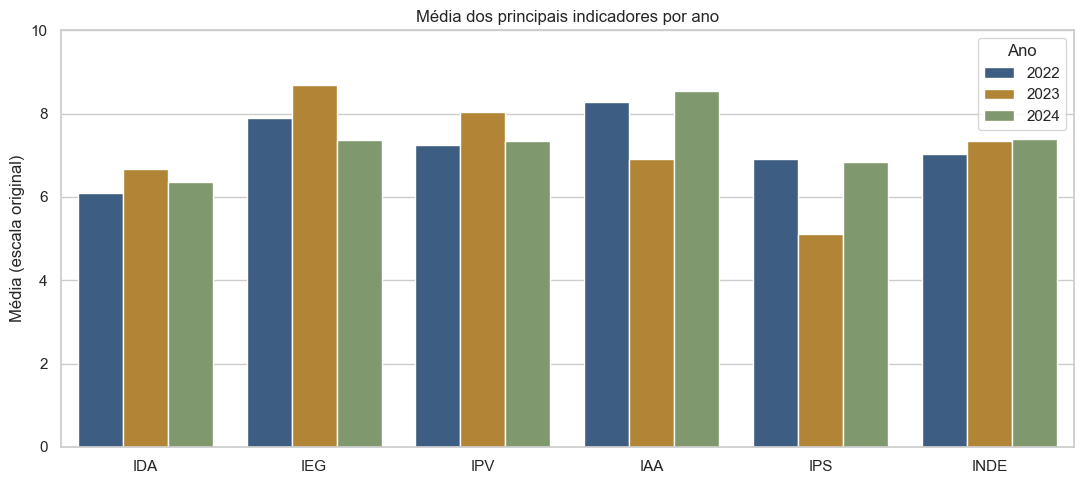

,,IDA,IPV
ANO,Indicador,,
2022,IEG,0.507449,0.540334
2023,IEG,0.446479,0.492018
2024,IEG,0.516812,0.550950


In [ ]:
# Calcula e compara as médias anuais dos principais indicadores em um gráfico
# e, em seguida, mede por ano a correlação de Spearman entre engajamento (IEG),
# desempenho acadêmico (IDA) e ponto de virada (IPV).

medias = painel.groupby("ANO")[["IDA", "IEG", "IPV", "IAA", "IPS", "INDE"]].mean().reset_index().melt("ANO", var_name="Indicador", value_name="Média")
fig, ax = plt.subplots(figsize=(11, 5))
sns.barplot(data=medias, x="Indicador", y="Média", hue="ANO", palette=PALETA, ax=ax)
ax.set(title="Média dos principais indicadores por ano", xlabel="", ylabel="Média (escala original)")
ax.set_ylim(0, 10)
ax.legend(title="Ano")
plt.tight_layout()
plt.show()

correlacoes_engajamento = (
    painel.groupby("ANO")[["IEG", "IDA", "IPV"]]
    .corr(method="spearman")
    .loc[(slice(None), "IEG"), ["IDA", "IPV"]]
    .rename_axis(index=["ANO", "Indicador"])
)
correlacoes_engajamento


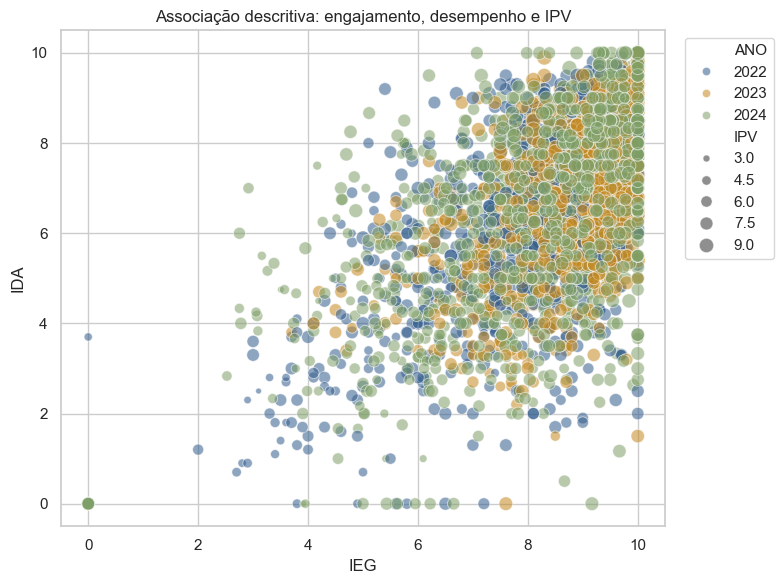

In [ ]:
# Filtra os registros com IEG, IDA e IPV preenchidos e gera um gráfico de dispersão
# para visualizar a associação entre engajamento (IEG) e desempenho (IDA),
# diferenciando os anos e representando o IPV pelo tamanho dos pontos.

dados_relacao = painel.dropna(subset=["IEG", "IDA", "IPV"])
fig, ax = plt.subplots(figsize=(8, 6))
sns.scatterplot(data=dados_relacao, x="IEG", y="IDA", hue="ANO", size="IPV", sizes=(18, 120), alpha=.55, palette=PALETA, ax=ax)
ax.set(title="Associação descritiva: engajamento, desempenho e IPV", xlabel="IEG", ylabel="IDA")
ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()


**Leitura:** o IEG apresenta associação positiva e moderada com o IDA, com correlações de Spearman entre 0,45 e 0,52 nos três anos. A associação entre IEG e IPV é um pouco mais forte, variando entre 0,49 e 0,55.

O padrão é semelhante nos três anos, indicando uma associação consistente entre engajamento, desempenho acadêmico e ponto de virada no período analisado.

Esses resultados descrevem associações entre os indicadores e não permitem concluir que o aumento do engajamento cause aumento do desempenho ou do ponto de virada.

### Pergunta 4: Autoavaliação (IAA) são coerentes com desempenho real (IDA/IEG)?

Depois de analisar desempenho, engajamento e ponto de virada, avaliamos a relação entre a autoavaliação do estudante (`IAA`) e os indicadores de desempenho observados.

A matriz utiliza correlação de Spearman e pares completos para cada comparação.

O objetivo é verificar o grau de associação entre a percepção do próprio estudante e os indicadores de desempenho, sem assumir que um indicador seja substituto do outro.

`IPP` deve ser interpretado somente nos períodos em que está disponível, a partir de 2023.

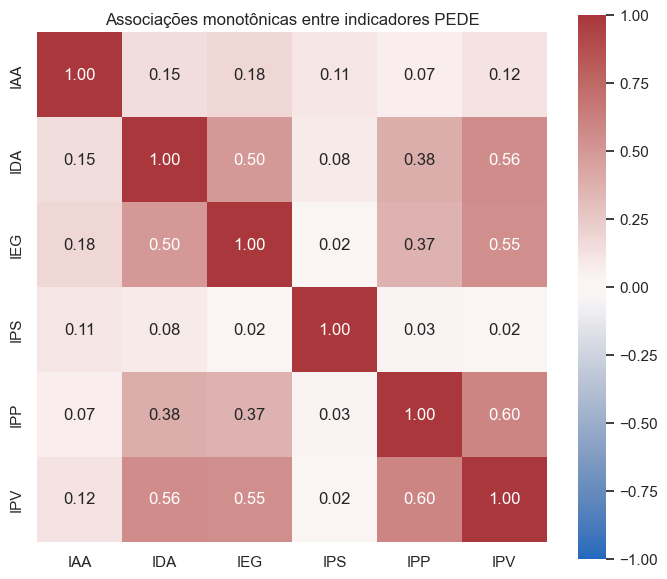

In [ ]:
# Calcula a correlação de Spearman entre os principais indicadores do painel
# e apresenta os resultados em um mapa de calor, facilitando a identificação
# das associações monotônicas entre os indicadores.

matriz = painel[["IAA", "IDA", "IEG", "IPS", "IPP", "IPV"]].corr(method="spearman")
fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(matriz, annot=True, fmt=".2f", cmap="vlag", center=0, vmin=-1, vmax=1, square=True, ax=ax)
ax.set_title("Associações monotônicas entre indicadores PEDE")
plt.tight_layout()
plt.show()


**Leitura:** a autoavaliação (`IAA`) apresenta associação fraca com os indicadores de desempenho analisados, com correlação de Spearman de 0,15 com `IDA` e 0,18 com `IEG`.

No conjunto analisado, portanto, a percepção do estudante apresenta baixa associação com os indicadores de desempenho medidos. Isso indica que o `IAA` deve ser interpretado como uma dimensão complementar, e não como substituto dos indicadores de desempenho.

A utilização do `IAA` como eventual sinal de alerta exigiria análises adicionais, especialmente uma avaliação temporal e preditiva, antes de definir sua utilidade operacional.

### Pergunta 5: Padrões psicossociais (IPS) que antecedem quedas de desempenho/engajamento

Nesta análise, investigamos se o `IPS` observado em um ano apresenta associação com a variação do `IDA` e do `IEG` no ano seguinte.

O objetivo é verificar se existe algum sinal temporal que justifique uma investigação posterior sobre o potencial preditivo do indicador.

A análise é exploratória: uma associação temporal não é suficiente para estabelecer que o IPS causa mudanças futuras no desempenho ou no engajamento.

In [ ]:
# Analisa se o IPS de um ano apresenta associação com as variações futuras de
# desempenho (ΔIDA) e engajamento (ΔIEG) no ano seguinte, calculando as
# correlações de Spearman para cada transição anual.

antecedencia = []
for origem, destino in [(2022, 2023), (2023, 2024)]:
    atual = painel.loc[painel["ANO"].eq(origem), ["RA", "IPS", "IDA", "IEG"]]
    proximo = painel.loc[painel["ANO"].eq(destino), ["RA", "IDA", "IEG"]]
    pares = atual.merge(proximo, on="RA", suffixes=("_atual", "_proximo")).dropna()
    pares["DELTA_IDA"] = pares["IDA_proximo"] - pares["IDA_atual"]
    pares["DELTA_IEG"] = pares["IEG_proximo"] - pares["IEG_atual"]
    antecedencia.append({
        "Transição": f"{origem}→{destino}",
        "n": len(pares),
        "Spearman IPS atual × ΔIDA": pares["IPS"].corr(pares["DELTA_IDA"], method="spearman"),
        "Spearman IPS atual × ΔIEG": pares["IPS"].corr(pares["DELTA_IEG"], method="spearman"),
    })

pd.DataFrame(antecedencia).round(3)


,Transição,n,Spearman IPS atual × ΔIDA,Spearman IPS atual × ΔIEG
0,2022→2023,574,0.029,-0.024
1,2023→2024,679,0.027,0.033


**Cuidado de interpretação:** as correlações temporais apresentadas são evidências exploratórias de associação e não isolam outros fatores que podem influenciar a evolução dos estudantes, como intervenções, maturação, mudanças de turma ou características dos estudantes que permaneceram na base.

Portanto, os resultados desta seção não devem ser interpretados como evidência de efeito causal ou como validação definitiva do `IPS` como indicador preditivo.

### Pergunta 6: IPP confirma ou contradiz a defasagem (IAN)?

O `IPP` está disponível somente a partir de 2023. Por esse motivo, a comparação com o IAN é restrita aos anos de 2023 e 2024.

Primeiro, analisamos a associação direta entre os dois indicadores. Em seguida, comparamos o `IPP` médio entre as diferentes faixas de defasagem utilizadas na Pergunta 1.

O objetivo é verificar se os dois indicadores apresentam padrões compatíveis ou divergentes no período em que ambos estão disponíveis.

In [ ]:
# Calcula a correlação de Spearman entre IPP e IAN separadamente por ano,
# considerando apenas registros com IPP preenchido, e também calcula a
# correlação para os dados de 2023 e 2024 agrupados.

correlacao_ipp_ian = []
for ano in sorted(painel.loc[painel["IPP"].notna(), "ANO"].unique()):
    dados = painel.loc[painel["ANO"].eq(ano), ["IPP", "IAN"]].dropna()
    correlacao_ipp_ian.append({
        "ANO": ano,
        "n": len(dados),
        "Spearman IPP x IAN": dados["IPP"].corr(dados["IAN"], method="spearman"),
    })

pool_ipp_ian = painel.loc[painel["IPP"].notna(), ["IPP", "IAN"]].dropna()
correlacao_ipp_ian.append({
    "ANO": "2023-2024 (agrupado)",
    "n": len(pool_ipp_ian),
    "Spearman IPP x IAN": pool_ipp_ian["IPP"].corr(pool_ipp_ian["IAN"], method="spearman"),
})
pd.DataFrame(correlacao_ipp_ian).round(3)


,ANO,n,Spearman IPP x IAN
0,2023,938,0.106
1,2024,1054,0.160
2,2023-2024 (agrupado),1992,0.131


In [ ]:
# Analisa o IPP por faixa de defasagem e ano, considerando apenas registros
# com IPP preenchido, e calcula a quantidade de alunos, a média e a mediana do IPP.

ipp_defasagem = (
    painel.loc[painel["IPP"].notna()]
    .groupby(["ANO", "FAIXA_DEFASAGEM"], observed=False)["IPP"]
    .agg(["count", "mean", "median"])
    .round(3)
)
ipp_defasagem


count   mean  median
ANO  FAIXA_DEFASAGEM                                
2023 Severa (≤ -2)                144  7.043   7.500
     Moderada (-1)                406  7.650   7.708
     Em fase / adiantado (≥ 0)    388  7.665   7.812
2024 Severa (≤ -2)                 93  7.205   7.292
     Moderada (-1)                441  7.456   7.500
     Em fase / adiantado (≥ 0)    520  7.688   7.708

**Leitura:** a correlação de Spearman entre `IPP` e `IAN` é positiva nos dois anos (0,106 em 2023 e 0,160 em 2024; 0,131 no conjunto 2023–2024).

A tabela de `IPP` médio por faixa de defasagem apresenta o mesmo sentido geral: o IPP médio é maior entre estudantes em fase/adiantados e menor entre estudantes com defasagem severa.

Os dois indicadores, portanto, apresentam um padrão descritivo consistente na mesma direção. Entretanto, a magnitude das correlações é baixa, indicando que eles capturam dimensões diferentes. O `IPP` não deve ser tratado como substituto da defasagem calculada.

### Pergunta 7: Quais comportamentos mais influenciam o ponto de virada (IPV)?

Nas perguntas anteriores, as relações com o `IPV` foram analisadas separadamente em cada ano (cross-sectional).

Nesta etapa, restringimos a análise aos estudantes que possuem registro nos três anos da base, utilizando `filtrar_alunos_com_todos_os_anos` (`src/eda_utils.py`).

A coorte resultante possui 468 estudantes e 1.404 observações aluno-ano. A correlação de Spearman apresentada a seguir é calculada sobre essas observações aluno-ano, considerando conjuntamente os três anos.

Esse recorte permite verificar se o padrão de associação entre `IPV` e os demais indicadores permanece semelhante quando restringimos a análise a estudantes com histórico completo no período.

A análise continua sendo associativa: ela não mede o efeito de mudanças individuais ao longo do tempo e não permite concluir que determinado comportamento cause mudança no `IPV`.

In [ ]:
# Seleciona os alunos com registros nos três anos (2022, 2023 e 2024),
# informa sua representatividade no painel e calcula as correlações de Spearman
# entre o IPV e os demais indicadores para essa coorte completa.

completos = filtrar_alunos_com_todos_os_anos(painel)
print(
    f"Estudantes com registro em 2022+2023+2024: {completos['RA'].nunique()} de "
    f"{painel['RA'].nunique()} ({completos['RA'].nunique() / painel['RA'].nunique():.1%}) "
    f"- {len(completos)} linhas (não confundir com as 3.030 linhas / 1.661 alunos do painel total)."
)

correlacao_ipv_completos = (
    completos[["IPV", "IEG", "IDA", "IAA", "IPS"]]
    .corr(method="spearman")["IPV"]
    .drop("IPV")
    .sort_values(ascending=False)
)
correlacao_ipv_completos.round(3).to_frame("Spearman com IPV (468 estudantes; 1.404 observações)")


Estudantes com registro em 2022+2023+2024: 468 de 1661 (28.2%) — 1404 linhas (não confundir com as 3.030 linhas / 1.661 alunos do painel total).


,Spearman com IPV (n=468)
IDA,0.562
IEG,0.539
IAA,0.109
IPS,0.018


**Leitura (468 estudantes; 1.404 observações aluno-ano):** `IDA` (0,562) e `IEG` (0,539) apresentam as maiores associações com `IPV`. `IAA` (0,109) apresenta associação fraca, enquanto `IPS` (0,018) apresenta associação próxima de zero.

A ordem das associações é consistente com a observada na leitura cross-sectional da Pergunta 3. Isso reforça a consistência descritiva do padrão entre os diferentes recortes analisados, embora não permita concluir que IDA ou IEG sejam causas do IPV.

### Pergunta 8: Quais combinações de indicadores (IDA + IEG + IPS + IPP) mais elevam o INDE?

Nesta análise, voltamos ao `INDE` como índice-síntese e avaliamos quais indicadores apresentam maior associação com seu valor.

Também analisamos a relação entre as categorias de `Pedra` e o INDE médio.

Como o INDE é construído a partir de indicadores do próprio PEDE, parte dessas associações é esperada pela própria composição do índice. Portanto, os resultados servem para identificar padrões e priorizar investigações, mas não permitem afirmar que um indicador isolado "eleva" ou "causa" aumento do INDE.

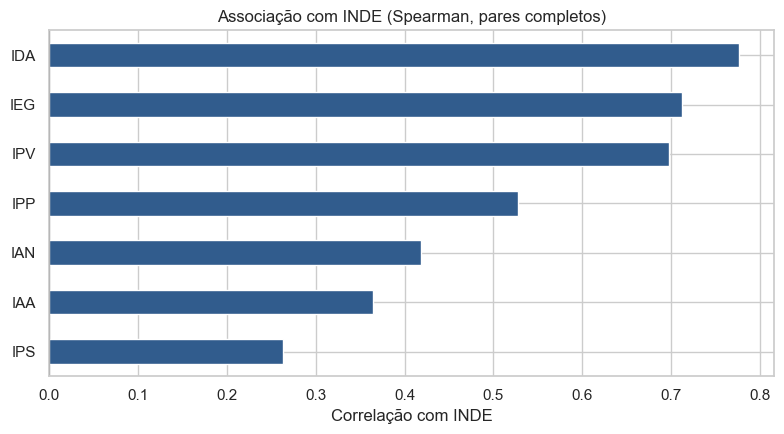

estudantes  inde_medio
ANO  PEDRA                           
2022 AGATA            250       6.606
     AMETISTA         348       7.528
     QUARTZO          132       5.243
     TOPAZIO          130       8.367
2023 AGATA            246       6.569
     AMETISTA         381       7.511
     QUARTZO           72       5.550
     TOPAZIO          232       8.441
     NaN               83         NaN
2024 AGATA            225       6.600
     AMETISTA         391       7.534
     QUARTZO          112       5.400
     TOPAZIO          326       8.468
     NaN              102         NaN

In [ ]:
# Calcula e visualiza as correlações de Spearman entre os componentes do INDE
# e o próprio INDE. Em seguida, resume por ano e Pedra a quantidade de alunos
# e o INDE médio de cada grupo.

componentes_inde = ["IAN", "IDA", "IEG", "IAA", "IPS", "IPP", "IPV", "INDE"]
correlacao_inde = painel[componentes_inde].corr(method="spearman")["INDE"].drop("INDE").sort_values()
fig, ax = plt.subplots(figsize=(8, 4.5))
correlacao_inde.plot(kind="barh", color="#315C8D", ax=ax)
ax.set(title="Associação com INDE (Spearman, pares completos)", xlabel="Correlação com INDE", ylabel="")
ax.axvline(0, color="#333333", linewidth=0.8)
plt.tight_layout()
plt.show()

pedra_inde = painel.groupby(["ANO", "PEDRA"], dropna=False).agg(estudantes=("RA", "size"), inde_medio=("INDE", "mean")).round(3)
pedra_inde


**Leitura:** `IDA` (0,777), `IEG` (0,713) e `IPV` (0,698) apresentam as maiores associações com o `INDE` entre os indicadores analisados. Na sequência aparecem `IPP` (0,528) e `IAN` (0,419), enquanto `IAA` (0,365) e `IPS` (0,264) apresentam associações menores.

A tabela de `Pedra × INDE` mostra também uma relação monotônica entre as categorias de Pedra e o INDE médio: Quartzo < Ágata < Ametista < Topázio.

Esses resultados descrevem a relação entre os indicadores e o índice-síntese. Como os componentes participam da própria construção do INDE, não devem ser interpretados como evidência de que um indicador isoladamente causa aumento do índice.

A associação relativamente menor do IPS será retomada na Pergunta 11 em conjunto com o resultado observado na análise temporal da Pergunta 5.

### Pergunta 9: Modelo preditivo de risco de defasagem

Nesta etapa, fazemos a transição da análise exploratória para o problema preditivo.

O alvo disponível representa o **risco de o estudante estar defasado no próximo ano observado**.

Também analisamos um segundo problema: a **incidência de nova defasagem**, restringindo a população aos estudantes que não estavam defasados no ano atual.

Esta seção apresenta a composição da base rotulada e as taxas observadas. O treinamento dos modelos, a validação temporal, a calibração, as métricas de desempenho e a análise dos limiares estão documentados no `03_modelagem_risco_temporal.ipynb`.

In [ ]:
# Avalia o risco de defasagem futura entre os alunos com alvo definido,
# calculando, por ano, a proporção em risco e a incidência de nova defasagem
# entre os alunos que não estavam defasados no ano atual.

rotulado = painel.dropna(subset=["ALVO_RISCO_DEFASAGEM_PROX_ANO"]).copy()
rotulado["DEFASADO_ATUAL"] = rotulado["DEFASAGEM_CALCULADA"] < 0
risco_futuro = rotulado.groupby("ANO").agg(
    n_rotulado=("RA", "size"),
    risco_futuro=("ALVO_RISCO_DEFASAGEM_PROX_ANO", "mean"),
)
incidencia = (
    rotulado.loc[~rotulado["DEFASADO_ATUAL"]]
    .groupby("ANO")
    .agg(n_nao_defasados=("RA", "size"), incidencia_nova_defasagem=("ALVO_RISCO_DEFASAGEM_PROX_ANO", "mean"))
)
risco_futuro.join(incidencia).style.format({"risco_futuro": "{:.1%}", "incidencia_nova_defasagem": "{:.1%}"})


,n_rotulado,risco_futuro,n_nao_defasados,incidencia_nova_defasagem
ANO,,,,
2022,600,61.0%,189,31.7%
2023,765,40.3%,370,22.7%


**Leitura:** a base rotulada apresenta diferentes níveis de cobertura e diferentes taxas de risco/incidência entre os anos.

Essas diferenças são importantes para interpretar os resultados do modelo, mas não são, por si só, evidência de mudança na eficácia do programa ou de mudança causal no risco dos estudantes.

Os resultados completos de desempenho dos modelos, os limiares operacionais e a validação temporal 2022→2023 (desenvolvimento) / 2023→2024 (teste temporal) estão apresentados no notebook 03. Eles não são repetidos aqui para evitar divergência entre os dois documentos.

### Pergunta 10: Efetividade do programa entre fases (Quartzo, Ágata, Ametista, Topázio)

Para analisar a evolução da classificação em Pedra, utilizamos o mesmo subconjunto de 468 estudantes com histórico completo identificado na Pergunta 7.

Comparamos a Pedra observada no primeiro ano (2022) com a Pedra observada no último ano disponível (2024) para cada estudante que possui classificação registrada nos dois extremos.

Essa abordagem permite observar trajetórias individuais no período, em vez de comparar somente médias cross-sectional entre anos.

A análise é descritiva: a mudança observada entre 2022 e 2024 não pode ser atribuída isoladamente ao programa, pois não há aqui um desenho de avaliação causal nem um grupo de comparação.

In [ ]:
# Compara a Pedra dos mesmos alunos entre 2022 e 2024, classificando a mudança
# como piora, manutenção ou melhora conforme a ordem das categorias, e resume
# a quantidade e o percentual de alunos em cada situação.

ordem_pedra = {"QUARTZO": 0, "AGATA": 1, "AMETISTA": 2, "TOPAZIO": 3}

pedra_2022 = completos.loc[completos["ANO"].eq(2022), ["RA", "PEDRA"]].rename(columns={"PEDRA": "PEDRA_2022"})
pedra_2024 = completos.loc[completos["ANO"].eq(2024), ["RA", "PEDRA"]].rename(columns={"PEDRA": "PEDRA_2024"})
transicao_pedra = pedra_2022.merge(pedra_2024, on="RA")

transicao_valida = transicao_pedra.dropna(subset=["PEDRA_2022", "PEDRA_2024"]).copy()
transicao_valida["ORDEM_2022"] = transicao_valida["PEDRA_2022"].map(ordem_pedra)
transicao_valida["ORDEM_2024"] = transicao_valida["PEDRA_2024"].map(ordem_pedra)
transicao_valida["MUDANCA"] = pd.cut(
    transicao_valida["ORDEM_2024"] - transicao_valida["ORDEM_2022"],
    bins=[-10, -0.5, 0.5, 10],
    labels=["Piorou", "Manteve", "Melhorou"],
)

print(
    f"n = {len(transicao_pedra)} estudantes com histórico completo (2022+2023+2024); "
    f"{len(transicao_valida)} com Pedra registrada em 2022 e 2024 "
    f"({len(transicao_pedra) - len(transicao_valida)} excluídos por Pedra ausente em algum dos dois anos)."
)
resumo_transicao = transicao_valida["MUDANCA"].value_counts().rename("estudantes").to_frame()
resumo_transicao["%"] = (resumo_transicao["estudantes"] / len(transicao_valida) * 100).round(1)
resumo_transicao


n = 468 estudantes com histórico completo (2022+2023+2024); 441 com Pedra registrada em 2022 e 2024 (27 excluídos por Pedra ausente em algum dos dois anos).


,estudantes,%
MUDANCA,,
Manteve,197,44.7
Melhorou,130,29.5
Piorou,114,25.9


In [ ]:
# Tabela Pedra x INDE médio por ano, já calculada na Pergunta 8

pedra_inde  


estudantes  inde_medio
ANO  PEDRA                           
2022 AGATA            250       6.606
     AMETISTA         348       7.528
     QUARTZO          132       5.243
     TOPAZIO          130       8.367
2023 AGATA            246       6.569
     AMETISTA         381       7.511
     QUARTZO           72       5.550
     TOPAZIO          232       8.441
     NaN               83         NaN
2024 AGATA            225       6.600
     AMETISTA         391       7.534
     QUARTZO          112       5.400
     TOPAZIO          326       8.468
     NaN              102         NaN

**Leitura (n=468, mesmo subconjunto da Pergunta 7):** entre os 441 estudantes com Pedra registrada nos dois extremos, 29,5% apresentaram melhora de categoria entre 2022 e 2024, 44,7% permaneceram na mesma categoria e 25,9% apresentaram piora.

Em conjunto com o INDE médio por Pedra e por ano, os resultados descrevem diferentes trajetórias entre os estudantes com histórico completo.

A presença de trajetórias de melhora, estabilidade e piora indica que existe heterogeneidade entre os estudantes. Uma análise complementar poderia investigar quais características estão associadas a essas trajetórias, especialmente entre os estudantes que apresentaram piora.

Esses resultados, entretanto, não permitem medir isoladamente a efetividade causal do programa.

### Pergunta 11: Insights livres/criatividade

Esta seção consolida os principais aprendizados das perguntas anteriores e destaca alguns pontos que podem orientar as próximas etapas do projeto.

1. Priorizar a defasagem calculada como medida de acompanhamento. Ela é utilizada na construção do alvo futuro e apresentou alta concordância com a coluna de defasagem fornecida pela fonte.

2. Apresentar tendências agregadas junto com análises de coortes pareadas, evitando interpretar mudanças de composição como evolução individual dos estudantes.

3. Tratar `IPP`, Inglês, `Indicado` e `Atingiu PV` de acordo com sua disponibilidade em cada ano, sem interpretar ausência como valor zero.

4. Não utilizar a `Pedra` recalculada como substituta da classificação fornecida pela fonte até que a regra utilizada pela Passos Mágicos seja confirmada. As duas classificações devem permanecer separadas.

5. Na modelagem, distinguir dois problemas: risco futuro de defasagem na população observada e incidência de nova defasagem entre estudantes que não estavam defasados no ano atual. A avaliação principal utiliza 2022→2023 para desenvolvimento e 2023→2024 para teste temporal.

In [ ]:
# Consolida as correlações de Spearman relacionadas ao IPS, reunindo sua
# associação com o INDE e sua relação com as variações futuras de IDA e IEG
# nas transições de 2022→2023 e 2023→2024.

insight_ips_cruzado = pd.Series({
    "IPS x INDE (Pergunta 8, peso no índice)": round(correlacao_inde["IPS"], 3),
    "IPS atual x Δ IDA, 2022→2023 (Pergunta 5)": antecedencia[0]["Spearman IPS atual × ΔIDA"],
    "IPS atual x Δ IDA, 2023→2024 (Pergunta 5)": antecedencia[1]["Spearman IPS atual × ΔIDA"],
    "IPS atual x Δ IEG, 2022→2023 (Pergunta 5)": antecedencia[0]["Spearman IPS atual × ΔIEG"],
    "IPS atual x Δ IEG, 2023→2024 (Pergunta 5)": antecedencia[1]["Spearman IPS atual × ΔIEG"],
})
insight_ips_cruzado.round(3).to_frame("Correlação de Spearman")


,Correlação de Spearman
"IPS x INDE (Pergunta 8, peso no índice)",0.264
"IPS atual x Δ IDA, 2022→2023 (Pergunta 5)",0.029
"IPS atual x Δ IDA, 2023→2024 (Pergunta 5)",0.027
"IPS atual x Δ IEG, 2022→2023 (Pergunta 5)",-0.024
"IPS atual x Δ IEG, 2023→2024 (Pergunta 5)",0.033


6. **Insight novo, cruzamento das Perguntas 5 e 8:** nas análises realizadas, o `IPS` apresenta associação próxima de zero com as variações futuras de `IDA` e `IEG` investigadas na Pergunta 5. Na Pergunta 8, também apresenta a menor associação com o `INDE` entre os indicadores analisados (Spearman ≈ 0,26).

Os dois resultados apontam para uma associação relativamente baixa do `IPS` com os desfechos analisados neste painel e neste desenho exploratório.

Isso levanta uma hipótese para investigação futura: verificar se a forma de coleta e mensuração do `IPS` é adequada para o papel que se pretende atribuir ao indicador, especialmente caso ele seja considerado como possível sinal de acompanhamento ou alerta. Os resultados atuais, porém, não são suficientes para concluir que o IPS não possui utilidade preditiva em outros contextos ou com outra forma de mensuração.

### Próxima etapa

A próxima etapa é consolidar as decisões metodológicas pendentes e desenvolver o notebook de modelagem, com comparação de modelos, validação temporal, métricas de classificação, calibração e análise de limiares operacionais.

As decisões de modelagem devem permanecer separadas das conclusões exploratórias apresentadas neste notebook.